Installations + Imports

In [ ]:

!pip install timm==0.4.5 --quiet
!pip install torchcodec --quiet

!pip install torch==2.9.0+cu126 --index-url https://download.pytorch.org/whl/cu126
!pip install torchaudio==2.9.0+cu126 --index-url https://download.pytorch.org/whl/cu126


import torch
import torchaudio


import os
import random
import numpy as np

import glob
import sys
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
import torch.optim as optim

print("Torch:", torch.__version__)
print("Cuda available:", torch.cuda.is_available())


Looking in indexes: https://download.pytorch.org/whl/cu126
Looking in indexes: https://download.pytorch.org/whl/cu126
Torch: 2.9.0+cu126
Cuda available: True


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Configuration + Paths + Seed

In [ ]:

BASE_PATH = "/content/drive/MyDrive/genres_original"
AST_MODELS_PATH = "/content/drive/MyDrive/ast/src/models"

if AST_MODELS_PATH not in sys.path:
    sys.path.append(AST_MODELS_PATH)

# Hyperparams
NUM_CLASSES = 10
SR = 22050
SEGMENT_SECONDS = 3
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 160
WIN_LENGTH = 400
INPUT_TDIM = 512
INPUT_FDIM = N_MELS
BATCH_SIZE = 8
NUM_EPOCHS = 10
LR = 3e-5
SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reproducibility
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()


Préparation GTZAN (split train/val/test)

In [4]:
genres = sorted(os.listdir(BASE_PATH))
filepaths = []
labels = []

for idx, genre in enumerate(genres):
    files = glob.glob(os.path.join(BASE_PATH, genre, "*.wav"))
    for f in files:
        filepaths.append(f)
        labels.append(idx)

X_temp, X_test, y_temp, y_test = train_test_split(
    filepaths, labels, test_size=0.15, random_state=SEED, stratify=labels)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=SEED, stratify=y_temp)

print("Train:", len(X_train))
print("Valid:", len(X_val))
print("Test :", len(X_test))


Train: 699
Valid: 151
Test : 150


Dataset AST + DataLoader

In [5]:
import librosa
# augmentations
time_mask = torchaudio.transforms.TimeMasking(time_mask_param=30)
freq_mask = torchaudio.transforms.FrequencyMasking(freq_mask_param=15)

class GTZANDatasetAST(Dataset):
    def __init__(self, files, labels, augment=False):
        self.files = files
        self.labels = labels
        self.sr = SR
        self.segment_samples = SR * SEGMENT_SECONDS
        self.augment = augment

    def load_audio(self, path):
        try:
            audio, sr = librosa.load(path, sr=self.sr)
            if len(audio.shape) > 1:
                audio = np.mean(audio, axis=0)
            return torch.tensor(audio, dtype=torch.float32).unsqueeze(0)
        except Exception as e:
            print(f"[CORRUPTED FILE] Skipping {path}: {e}")
            return None

    def __getitem__(self, idx):
        path = self.files[idx]
        label = self.labels[idx]

        audio = self.load_audio(path)
        if audio is None:
            # Skip fichier corrompu
            return self.__getitem__((idx + 1) % len(self.files))

        L = audio.shape[1]

        # crop/pad
        if L < self.segment_samples:
            audio = F.pad(audio, (0, self.segment_samples - L))
        else:
            start = random.randint(0, L - self.segment_samples) if self.augment else (L - self.segment_samples)//2
            audio = audio[:, start:start + self.segment_samples]

        # mel spectrogram
        mel = librosa.feature.melspectrogram(
            y=audio.squeeze(0).numpy(),
            sr=self.sr,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            win_length=WIN_LENGTH,
            n_mels=N_MELS
        )
        mel = librosa.power_to_db(mel, ref=np.max)
        mel = (mel - mel.mean()) / (mel.std() + 1e-6)
        mel = torch.tensor(mel.T, dtype=torch.float32)  # [T, F]

        # pad/truncate
        T = mel.shape[0]
        if T < INPUT_TDIM:
            mel = F.pad(mel, (0,0,0,INPUT_TDIM - T))
        else:
            start = random.randint(0, T - INPUT_TDIM) if self.augment else (T - INPUT_TDIM)//2
            mel = mel[start:start + INPUT_TDIM]

        # SpecAugment
        if self.augment:
            tmp = mel.transpose(0,1).unsqueeze(0)
            tmp = freq_mask(tmp)
            tmp = time_mask(tmp)
            mel = tmp.squeeze(0).transpose(0,1)

        return mel.float(), torch.tensor(label)

    def __len__(self):
        return len(self.files)


# DataLoaders
train_dataset = GTZANDatasetAST(X_train, y_train, augment=True)
val_dataset   = GTZANDatasetAST(X_val,   y_val)
test_dataset  = GTZANDatasetAST(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Sample shape:", train_dataset[0][0].shape)


Sample shape: torch.Size([512, 128])


Import et création du modèle AST

In [6]:
!pip install timm==0.4.5
!pip install wget
!pip install einops


In [7]:
import os

# chemin réel de tes poids
real_pretrained_dir = "/content/drive/MyDrive/ast/pretrained_models"

# créer un lien symbolique vers le chemin attendu par AST
!mkdir -p /content/../../  # assure que le dossier parent existe
!ln -sfn "{real_pretrained_dir}" /content/../../pretrained_models


In [ ]:
from ast_models import ASTModel

model = ASTModel(
        label_dim=NUM_CLASSES,
        fstride=10,
        tstride=10,
        input_fdim=INPUT_FDIM,
        input_tdim=INPUT_TDIM,
        imagenet_pretrain=True,
        audioset_pretrain=True,
        model_size="base384",
        verbose=True
    ).to(DEVICE)

    # Geler une partie du modèle (fine-tuning partiel)
for name, param in model.named_parameters():
        if "blocks" not in name and "mlp_head" not in name:
            param.requires_grad = False

    # Statistiques des paramètres
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"Trainable parameters: {trainable_params}/{total_params}")


/content/drive/MyDrive/ast/src/models/ast_models.py:165: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast()


---------------AST Model Summary---------------
ImageNet pretraining: True, AudioSet pretraining: True
frequncey stride=10, time stride=10
number of patches=600
Trainable: 85063690/87264474


Optimizer + Scheduler + Loss

In [ ]:

optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR, weight_decay=1e-4
    )



/tmp/ipython-input-3205539054.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [ ]:
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
criterion = torch.nn.CrossEntropyLoss()
scaler = GradScaler()


Fonction d’évaluation

In [10]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            out = model(X)
            preds = torch.argmax(out, dim=1)
            all_preds += preds.cpu().tolist()
            all_labels += y.cpu().tolist()

    acc = accuracy_score(all_labels, all_preds)
    return acc, np.array(all_labels), np.array(all_preds)


Entraînement complet + sauvegarde meilleur modèle

In [11]:
best_val = 0
SAVE_PATH = "/content/best_ast_gtzan.pth"

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0

    for X, y in train_loader:
        X, y = X.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()

        with autocast():
            out = model(X)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * X.size(0)

    scheduler.step()

    val_acc, _, _ = evaluate(model, val_loader)
    print(f"Epoch {epoch+1} | Loss={total_loss/len(train_dataset):.4f} | Val Acc={val_acc:.4f}")

    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        print("🔥 Nouveau meilleur modèle sauvegardé")


/tmp/ipython-input-704291757.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1 | Loss=1.4668 | Val Acc=0.6954
🔥 Nouveau meilleur modèle sauvegardé


/tmp/ipython-input-704291757.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 2 | Loss=0.7991 | Val Acc=0.6821


/tmp/ipython-input-704291757.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...

Epoch 8 | Loss=0.2412 | Val Acc=0.8079


/tmp/ipython-input-704291757.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 9 | Loss=0.1932 | Val Acc=0.8543


/tmp/ipython-input-704291757.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 10 | Loss=0.1768 | Val Acc=0.8675
🔥 Nouveau meilleur modèle sauvegardé


Test final + rapport + matrice de confusion

/tmp/ipython-input-1421155.py:16: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(path, sr=self.sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


[CORRUPTED FILE] Skipping /content/drive/MyDrive/genres_original/jazz/jazz.00054.wav: 
Test accuracy: 0.8666666666666667

Classification report:
              precision    recall  f1-score   support

       blues       0.92      0.73      0.81        15
   classical       1.00      1.00      1.00        15
     country       0.81      0.87      0.84        15
       disco       0.81      0.87      0.84        15
      hiphop       0.94      1.00      0.97        15
        jazz       0.88      1.00      0.93        14
       metal       0.93      0.88      0.90        16
         pop       0.82      0.93      0.88        15
      reggae       0.92      0.73      0.81        15
        rock       0.67      0.67      0.67        15

    accuracy                           0.87       150
   macro avg       0.87      0.87      0.87       150
weighted avg       0.87      0.87      0.87       150



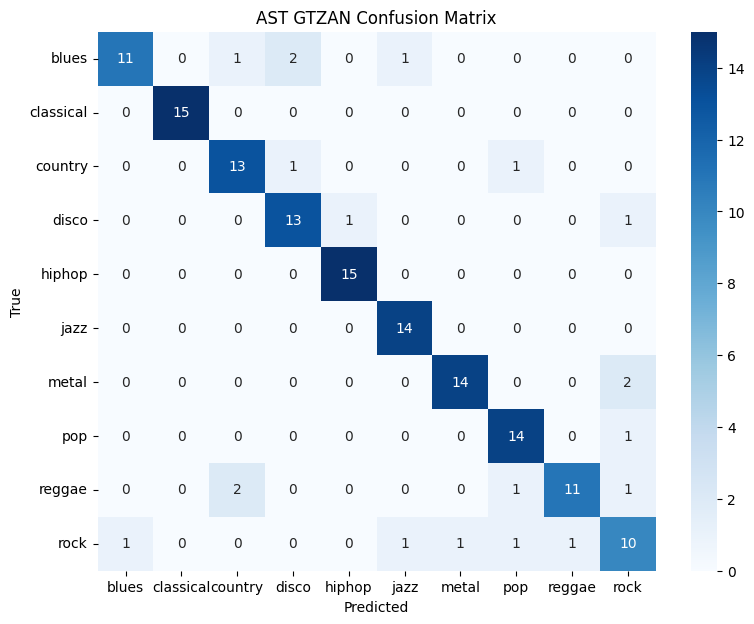

In [12]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))

test_acc, y_true, y_pred = evaluate(model, test_loader)
print("Test accuracy:", test_acc)

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=genres))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=genres, yticklabels=genres, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("AST GTZAN Confusion Matrix")
plt.show()


In [14]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [15]:
from sklearn.metrics import accuracy_score, classification_report

model.eval()  # mode évaluation
all_preds = []
all_labels = []

with torch.no_grad():  # pas de calcul de gradient
    for X_batch, y_batch in test_loader:  # ou test_loader
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)  # classe prédite = argmax
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())




acc = accuracy_score(all_labels, all_preds)
print(f"test Accuracy: {acc*100:.2f}%")






/tmp/ipython-input-1421155.py:16: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(path, sr=self.sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


[CORRUPTED FILE] Skipping /content/drive/MyDrive/genres_original/jazz/jazz.00054.wav: 
test Accuracy: 86.67%
